# Project 3 Assignment

## Assignment Overview & Instructions

The objective of project 3 is to perform keyword network analysis and word frequency
analysis.  
Please complete the following 7 tasks in this assessment, using the instructions indicated below.   

**Note:** You may create your own custom functions if necessary to complete the tasks.

### Task 1: Import the Dataset for use in your Notebook.   

You can find the source dataset [here](https://drive.google.com/file/d/1YJe45YXo0xSkFClGPBhKYLzupFEyGadK/view?usp=sharing)

Task 1: Import the dataset for use in your notebook. Load the CSV file into a pandas dataframe and display the first few rows. Remember that the rows represent different articles.

In [17]:

#pip install pandas

In [18]:
## YOUR CODE HERE
import pandas as pd
df = pd.read_csv('keywords_data.csv')

df.head()

,Title,Keyword 1,Keyword 2,Keyword 3,Keyword 4,Keyword 5,Keyword 6,Keyword 7,Keyword 8,Keyword 9,Keyword 10,Keyword 11,Keyword 12
0,Feb/03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Meta-Analyses of Financial Performance and Equ...,EQUITY,ORGANIZATIONAL sociology,PERFORMANCE,META-analysis,PSYCHOMETRICS,ORGANIZATIONAL research,FINANCIAL performance,AGENCY theory,ORGANIZATIONAL effectiveness,ORGANIZATIONAL behavior,CORPORATE governance,NaN
3,"Home Country Environments, Corporate Diversifi...",DIVERSIFICATION in industry,BUSINESS planning,PERFORMANCE standards,EMPLOYEES -- Rating of,CORPORATE culture,STRATEGIC planning,ORGANIZATIONAL effectiveness,MANAGEMENT science,MANAGEMENT research,PRODUCT management,NaN,NaN
4,Safeguarding Investments in Asymmetric Interor...,INTERORGANIZATIONAL relations,INTERGROUP relations,BUSINESS communication,INVESTMENTS,SUPPLY chains,KNOWLEDGE management,INTERORGANIZATIONAL networks,CORPORATE governance,GROUP decision making,INTELLECTUAL capital,NaN,NaN


### **Task 2:**  Write a Python code to extract keyword data from the above file. 
Write a Python code to extract keyword data from the above file and convert it to a weighted adjacency matrix. See the figure below to understand the process



Task 2: Extract the keyword data from your dataframe from Task 1. 

Note that you do not need to do extensive cleaning hear – only converting to lowercase is fine. There is no need to remove hyphens and special characters etc. You also do not need the article title here. 

Now create a co-occurrence matrix where:
•    Rows and columns represent unique keywords
•    Cell values show how many times two keywords appeared together in the same article
•    The matrix should be symmetric

Please note that the co-occurrence may not be treated as uni-directional. As an example, this means that the pairs (‘a’,’cat’) and (‘cat’, ‘a’) should be counted as two occurrences of the words ‘a’ and ‘cat.’ 

Hint: For each article, find all keyword pairs and increment their co-occurrence count.

![Task Two - Adjacency matrix](Task%202%20-%20Figure%201.png)

In [19]:
#pip install nltk

In [20]:
## YOUR CODE HERE

# Step 1: Get keyword columns (all columns except 'Title')
keyword_cols = [col for col in df.columns if col != 'Title']

# Step 2: For each article, collect its keywords as a list (lowercase, skip empty)
keyword_lists = []
for i, row in df[keyword_cols].iterrows():
    kws = []
    for kw in row:
        if isinstance(kw, str) and kw.strip() != '':
            kws.append(kw.strip().lower())
    keyword_lists.append(kws)

# Step 3: Get all unique keywords
all_keywords = []
for kws in keyword_lists:
    for kw in kws:
        if kw not in all_keywords:
            all_keywords.append(kw)
all_keywords = sorted(all_keywords)

# Step 4: Build empty co-occurrence matrix
co_matrix = pd.DataFrame(0, index=all_keywords, columns=all_keywords)

# Step 5: Fill the matrix - for each article, loop through every pair of keywords
for kws in keyword_lists:
    for kw1 in kws:
        for kw2 in kws:
            if kw1 != kw2:  # don't count a keyword paired with itself
                co_matrix.loc[kw1, kw2] += 1

print(co_matrix.shape)
co_matrix


(248, 248)


,agency theory,aggression (psychology),ambivalence,anger in the workplace,behavioral research,boards of directors,break-even analysis,burnout (psychology),business communication,business enterprises,...,violence in the workplace,wage payment systems,wages,women -- employment,women employees,work & family,work attitudes,work environment,work environment -- psychological aspects,workflow
agency theory,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
aggression (psychology),0,0,0,1,0,0,0,0,0,0,...,1,0,0,0,0,0,1,2,0,0
ambivalence,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
anger in the workplace,0,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,1,1,0,0
behavioral research,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
work & family,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,0,0,0,0,0
work attitudes,0,1,0,1,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0
work environment,0,2,0,1,0,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0
work environment -- psychological aspects,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### **Task 3:**  Read the adjacency matrix and convert it into a weighted network

Read the adjacency matrix and convert It into a weighted network. Then use networkX to create a graph object from your adjacency matrix. Print the number of nodes and edges. There is no need to visualize the graph.

In [21]:
## YOUR CODE HERE
import networkx as nx

# Create a weighted graph from the co-occurrence matrix
G = nx.from_pandas_adjacency(co_matrix)

# Print the number of nodes and edges
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())


Number of nodes: 248
Number of edges: 2141


### **Task 4:**  Compute node degree and strength

Calculate and store two metrics for each keyword:

Degree: Number of unique keywords it connects to
Strength: Sum of all connection weights

In [22]:
## YOUR CODE HERE

# Degree: number of unique keywords each node connects to
degree_dict = {}
for node in G.nodes():
    degree_dict[node] = G.degree(node)

# Strength: sum of all edge weights for each node
strength_dict = {}
for node in G.nodes():
    total_weight = 0
    for neighbor in G.neighbors(node):
        total_weight = total_weight + G[node][neighbor]['weight']
    strength_dict[node] = total_weight

# Store in a dataframe for easy viewing
metrics_df = pd.DataFrame({
    'degree': degree_dict,
    'strength': strength_dict
})

print(metrics_df)


                                           degree  strength
agency theory                                  38        48
aggression (psychology)                        18        20
ambivalence                                     9         9
anger in the workplace                         11        11
behavioral research                             9         9
...                                           ...       ...
work & family                                   9         9
work attitudes                                 11        11
work environment                               26        31
work environment -- psychological aspects      10        10
workflow                                       10        10

[248 rows x 2 columns]


### **Task 5:**  Show the top 10 nodes by degree and top 10 nodes by strength

Show the top 10 Nodes by degree and top 10 nodes by strength. Display two ranked lists showing the most important keywords by each metric.

In [23]:
## YOUR CODE HERE

# Top 10 nodes by degree
top_degree = metrics_df.sort_values('degree', ascending=False).head(10)
print("Top 10 Keywords by Degree:")
print(top_degree[['degree']])

print()

# Top 10 nodes by strength
top_strength = metrics_df.sort_values('strength', ascending=False).head(10)
print("Top 10 Keywords by Strength:")
print(top_strength[['strength']])


Top 10 Keywords by Degree:
                              degree
organizational behavior          166
organizational effectiveness     104
management science               102
personnel management              93
decision making                   90
organizational structure          74
organizational sociology          66
strategic planning                66
industrial management             64
corporate governance              62

Top 10 Keywords by Strength:
                              strength
organizational behavior            265
organizational effectiveness       144
management science                 136
personnel management               126
decision making                    112
organizational structure           107
organizational sociology            96
corporate governance                85
industrial management               84
strategic planning                  80


### **Task 6:** Show the top 10 node pairs by weight

Show the top 10 node pairs by weight. Identify and display the 10 keyword pairs that co-occur most frequently.

In [24]:
## YOUR CODE HERE

# Get all edges and their weights
edge_list = []
for node1, node2, data in G.edges(data=True):
    edge_list.append((node1, node2, data['weight']))

# Sort by weight (highest first)
edge_list.sort(key=lambda x: x[2], reverse=True)

# Show the top 10 pairs
print("Top 10 Keyword Pairs by Weight:")
for i in range(10):
    kw1, kw2, weight = edge_list[i]
    print(f"{i+1}. ({kw1}, {kw2}) - Weight: {weight}")


Top 10 Keyword Pairs by Weight:
1. (organizational behavior, organizational effectiveness) - Weight: 11
2. (organizational behavior, organizational structure) - Weight: 9
3. (organizational behavior, personnel management) - Weight: 8
4. (management science, organizational behavior) - Weight: 7
5. (corporate governance, organizational behavior) - Weight: 6
6. (decision making, organizational behavior) - Weight: 6
7. (organizational behavior, organizational sociology) - Weight: 6
8. (organizational effectiveness, organizational structure) - Weight: 6
9. (industrial management, organizational behavior) - Weight: 5
10. (industrial relations, organizational behavior) - Weight: 5


### **Task 7:** Plot strength on y-axis and degree on x-axis

Plot strength on y-axis and degree on x-axis. Create a scatter plot showing the relationship between degree (x-axis) and strength (y-axis). Label your axes and add a title.

In [25]:
#%pip install matplotlib

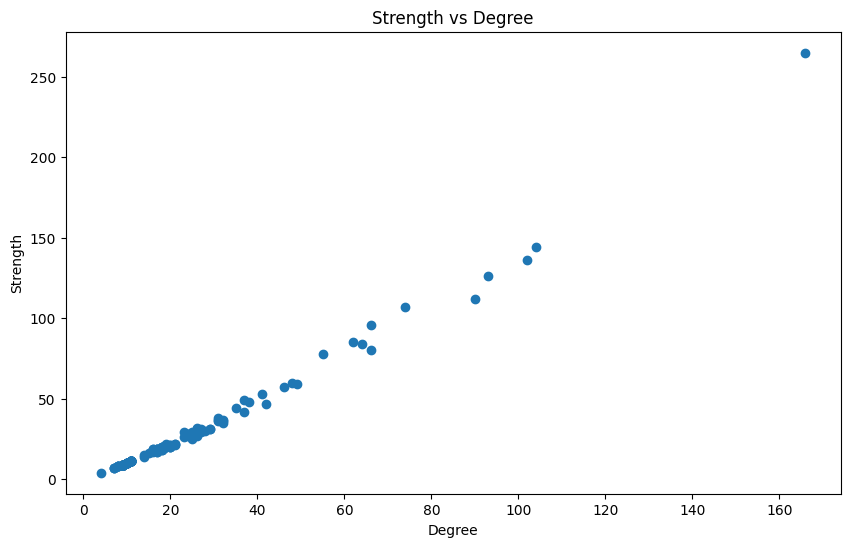

In [26]:
## YOUR CODE HERE
import matplotlib.pyplot as plt

# Create a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(metrics_df['degree'], metrics_df['strength'])

# Add labels and title
plt.xlabel('Degree')
plt.ylabel('Strength')
plt.title('Strength vs Degree')

plt.show()


## Submitting your Project

Once you've completed your project, it's time to submit your work for grading.   
This week, you will submit your code file `Project 3.ipynb` to the following Staff Graded Assignment for review.  

In order to submit your work, please follow the steps below:
1. Verify you've saved your work using the `Save` button within the Jupyter Notebook 
2. Download this notebook using the `File` -> `Download As` -> Choose the `Notebook (.ipynb)` format.
3. Access the following Step 2: Submit Project 3 item.
4. Complete all prompted fields, and upload your Jupyter Notebook file (Project 3.ipynb) in the indicated field.
5. Submit your notebook to "Step 2: Submit Project 3" by the deadline indicated within your course view for the Project 3 Assignment item.

Congratulations on completing the Project 3 Assignment!